In [1]:
import pandas as pd 

df1 = pd.read_csv('part_of_reviews.csv')
df2 = pd.read_csv('part_of_reviews (1).csv')
df3 = pd.read_csv('part_of_reviews (2).csv')
df = pd.concat([df1, df2, df3])


In [2]:
import matplotlib.pyplot as plt



def safe_eval(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return val
        else:
            return [val]
    except:
        return [x]

df["reason_n"] = df["reason_n"].apply(safe_eval)
df["reason_p"] = df["reason_p"].apply(safe_eval)


In [9]:
import pandas as pd
import ast


def safe_eval(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return val
        else:
            return [val]
    except:
        return [x]

price_keywords = ["Цены", "цены", "Стоимость", "стоимость", "Дорого", "дорого", "Дешево", "дешево"]


def contains_price(reasons):
    return any(any(k in str(r) for k in price_keywords) for r in reasons)

df["price_negative"] = df["reason_n"].apply(contains_price)
df["price_positive"] = df["reason_p"].apply(contains_price)

summary = []

for company in df["company"].unique():
    data = df[df["company"] == company]
    
    neg_total = (data["sentiment"] == "negative").sum()
    pos_total = (data["sentiment"] == "positive").sum()
    
    neg_price = data.loc[data["sentiment"] == "negative", "price_negative"].sum()
    pos_price = data.loc[data["sentiment"] == "positive", "price_positive"].sum()
    
    summary.append({
        "company": company,
        "neg_total": neg_total,
        "neg_price": neg_price,
        "neg_price_share_%": round(100 * neg_price / neg_total, 2) if neg_total > 0 else 0,
        "pos_total": pos_total,
        "pos_price": pos_price,
        "pos_price_share_%": round(100 * pos_price / pos_total, 2) if pos_total > 0 else 0,
    })

price_df = pd.DataFrame(summary)
print(price_df)


   company  neg_total  neg_price  neg_price_share_%  pos_total  pos_price  \
0     Папа        620         66              10.65        416         19   
1    Додо:         60          4               6.67        416         31   
2  Zotman:         90         12              13.33        426         53   

   pos_price_share_%  
0               4.57  
1               7.45  
2              12.44  


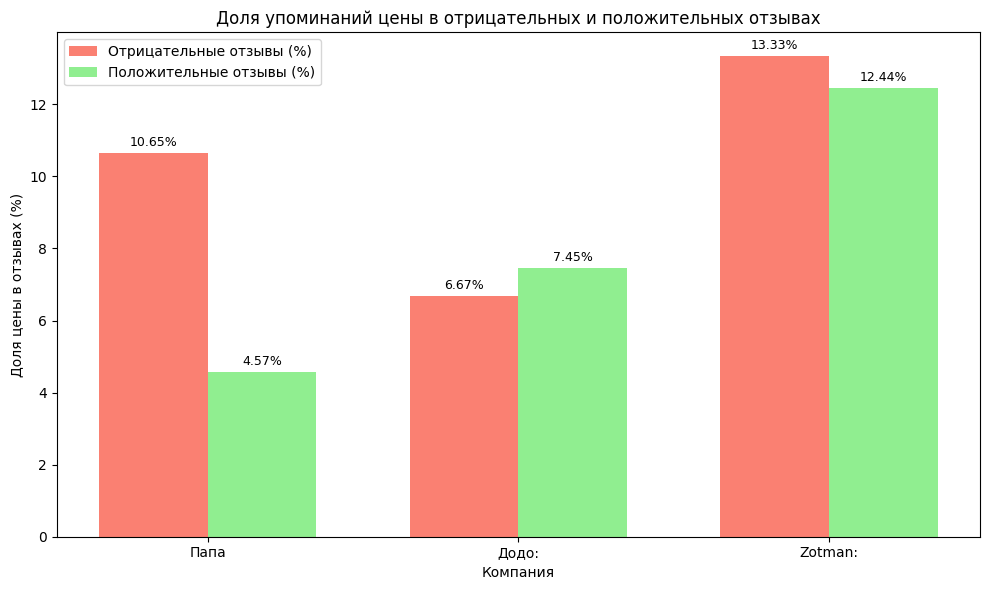

In [11]:
import numpy as np
companies = price_df['company']
neg_share = price_df['neg_price_share_%']
pos_share = price_df['pos_price_share_%']

x = np.arange(len(companies))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, neg_share, width, label='Отрицательные отзывы (%)', color='salmon')
bars2 = ax.bar(x + width/2, pos_share, width, label='Положительные отзывы (%)', color='lightgreen')

ax.set_xlabel('Компания')
ax.set_ylabel('Доля цены в отзывах (%)')
ax.set_title('Доля упоминаний цены в отрицательных и положительных отзывах')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.legend()

def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_values(bars1)
add_values(bars2)

plt.tight_layout()
plt.show()

   company  neg_total  neg_delivery  neg_delivery_share_%  pos_total  \
0     Папа        620           361                 58.23        416   
1    Додо:         60            16                 26.67        416   
2  Zotman:         90            30                 33.33        426   

   pos_delivery  pos_delivery_share_%  
0           132                 31.73  
1            96                 23.08  
2            88                 20.66  


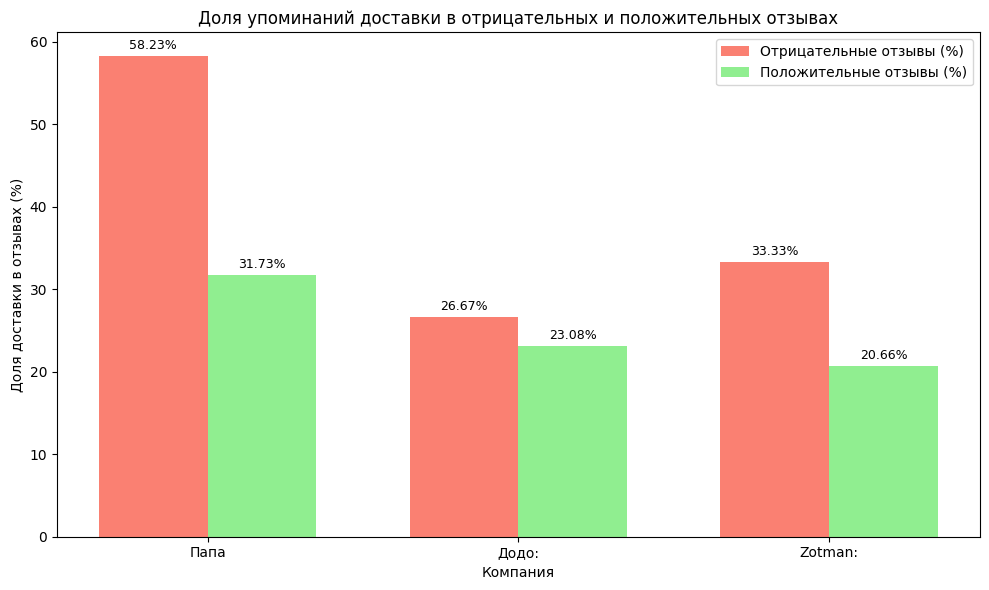

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

delivery_keywords = ["Доставка", "доставка", "Качество доставки", "доставки", "Доставкой", "доставкой", "Доставить", "доставить", "Доставили", "доставили", "Курьер", "курьер", "Курьера", "курьера", "Доставщик", "доставщик"]

def contains_delivery(reasons):
    return any(any(k in str(r) for k in delivery_keywords) for r in reasons)

df["delivery_negative"] = df["reason_n"].apply(contains_delivery)
df["delivery_positive"] = df["reason_p"].apply(contains_delivery)

summary = []

for company in df["company"].unique():
    data = df[df["company"] == company]
    
    neg_total = (data["sentiment"] == "negative").sum()
    pos_total = (data["sentiment"] == "positive").sum()
    
    neg_delivery = data.loc[data["sentiment"] == "negative", "delivery_negative"].sum()
    pos_delivery = data.loc[data["sentiment"] == "positive", "delivery_positive"].sum()
    
    summary.append({
        "company": company,
        "neg_total": neg_total,
        "neg_delivery": neg_delivery,
        "neg_delivery_share_%": round(100 * neg_delivery / neg_total, 2) if neg_total > 0 else 0,
        "pos_total": pos_total,
        "pos_delivery": pos_delivery,
        "pos_delivery_share_%": round(100 * pos_delivery / pos_total, 2) if pos_total > 0 else 0,
    })

delivery_df = pd.DataFrame(summary)
print(delivery_df)

companies = delivery_df['company']
neg_share = delivery_df['neg_delivery_share_%']
pos_share = delivery_df['pos_delivery_share_%']

x = np.arange(len(companies))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, neg_share, width, label='Отрицательные отзывы (%)', color='salmon')
bars2 = ax.bar(x + width/2, pos_share, width, label='Положительные отзывы (%)', color='lightgreen')

ax.set_xlabel('Компания')
ax.set_ylabel('Доля доставки в отзывах (%)')
ax.set_title('Доля упоминаний доставки в отрицательных и положительных отзывах')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.legend()

def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_values(bars1)
add_values(bars2)

plt.tight_layout()
plt.show()

   company  neg_total  neg_food_quality  neg_food_quality_share_%  pos_total  \
0     Папа        620               243                     39.19        416   
1    Додо:         60                23                     38.33        416   
2  Zotman:         90                40                     44.44        426   

   pos_food_quality  pos_food_quality_share_%  
0               371                     89.18  
1               337                     81.01  
2               390                     91.55  


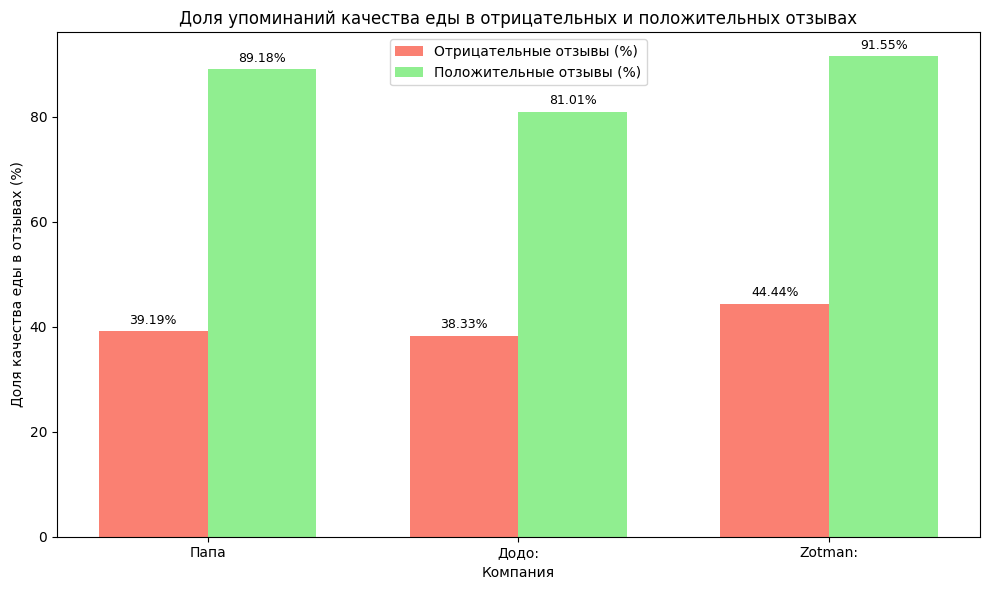

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


food_quality_keywords = ["Качество еды", "качество", "Вкусно", "вкусно", "Невкусно", "невкусно", "Еда", "еда", "Пицца", "пицца", "Вкус", "вкус", "Качеством", "качеством", "Свежесть", "свежесть", "Ингредиенты", "ингредиенты"]

def contains_food_quality(reasons):
    return any(any(k in str(r) for k in food_quality_keywords) for r in reasons)

df["food_quality_negative"] = df["reason_n"].apply(contains_food_quality)
df["food_quality_positive"] = df["reason_p"].apply(contains_food_quality)

summary = []

for company in df["company"].unique():
    data = df[df["company"] == company]
    
    neg_total = (data["sentiment"] == "negative").sum()
    pos_total = (data["sentiment"] == "positive").sum()
    
    neg_food_quality = data.loc[data["sentiment"] == "negative", "food_quality_negative"].sum()
    pos_food_quality = data.loc[data["sentiment"] == "positive", "food_quality_positive"].sum()
    
    summary.append({
        "company": company,
        "neg_total": neg_total,
        "neg_food_quality": neg_food_quality,
        "neg_food_quality_share_%": round(100 * neg_food_quality / neg_total, 2) if neg_total > 0 else 0,
        "pos_total": pos_total,
        "pos_food_quality": pos_food_quality,
        "pos_food_quality_share_%": round(100 * pos_food_quality / pos_total, 2) if pos_total > 0 else 0,
    })

food_quality_df = pd.DataFrame(summary)
print(food_quality_df)

companies = food_quality_df['company']
neg_share = food_quality_df['neg_food_quality_share_%']
pos_share = food_quality_df['pos_food_quality_share_%']

x = np.arange(len(companies))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, neg_share, width, label='Отрицательные отзывы (%)', color='salmon')
bars2 = ax.bar(x + width/2, pos_share, width, label='Положительные отзывы (%)', color='lightgreen')

ax.set_xlabel('Компания')
ax.set_ylabel('Доля качества еды в отзывах (%)')
ax.set_title('Доля упоминаний качества еды в отрицательных и положительных отзывах')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.legend()

def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_values(bars1)
add_values(bars2)

plt.tight_layout()
plt.show()

   company  neg_total  neg_assortment  neg_assortment_share_%  pos_total  \
0     Папа        620              17                    2.74        416   
1    Додо:         60               2                    3.33        416   
2  Zotman:         90               3                    3.33        426   

   pos_assortment  pos_assortment_share_%  
0              31                    7.45  
1              33                    7.93  
2              78                   18.31  


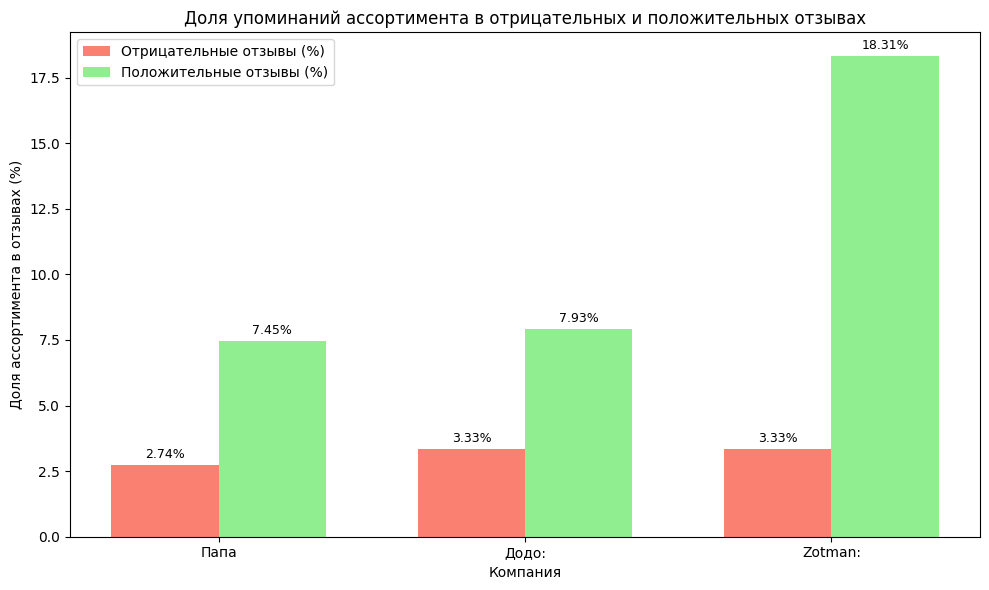

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


assortment_keywords = ["Ассортимент", "ассортимент", "Выбор", "выбор", "Меню", "меню", "Разнообразие", "разнообразие", "Ассортимента", "ассортимента", "Варианты", "варианты", "Опции", "опции"]

def contains_assortment(reasons):
    return any(any(k in str(r) for k in assortment_keywords) for r in reasons)

df["assortment_negative"] = df["reason_n"].apply(contains_assortment)
df["assortment_positive"] = df["reason_p"].apply(contains_assortment)

summary = []

for company in df["company"].unique():
    data = df[df["company"] == company]
    
    neg_total = (data["sentiment"] == "negative").sum()
    pos_total = (data["sentiment"] == "positive").sum()
    
    neg_assortment = data.loc[data["sentiment"] == "negative", "assortment_negative"].sum()
    pos_assortment = data.loc[data["sentiment"] == "positive", "assortment_positive"].sum()
    
    summary.append({
        "company": company,
        "neg_total": neg_total,
        "neg_assortment": neg_assortment,
        "neg_assortment_share_%": round(100 * neg_assortment / neg_total, 2) if neg_total > 0 else 0,
        "pos_total": pos_total,
        "pos_assortment": pos_assortment,
        "pos_assortment_share_%": round(100 * pos_assortment / pos_total, 2) if pos_total > 0 else 0,
    })

assortment_df = pd.DataFrame(summary)
print(assortment_df)

companies = assortment_df['company']
neg_share = assortment_df['neg_assortment_share_%']
pos_share = assortment_df['pos_assortment_share_%']

x = np.arange(len(companies))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, neg_share, width, label='Отрицательные отзывы (%)', color='salmon')
bars2 = ax.bar(x + width/2, pos_share, width, label='Положительные отзывы (%)', color='lightgreen')

ax.set_xlabel('Компания')
ax.set_ylabel('Доля ассортимента в отзывах (%)')
ax.set_title('Доля упоминаний ассортимента в отрицательных и положительных отзывах')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.legend()

def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_values(bars1)
add_values(bars2)

plt.tight_layout()
plt.show()

   company  neg_total  neg_staff  neg_staff_share_%  pos_total  pos_staff  \
0     Папа        620        206              33.23        416        192   
1    Додо:         60         14              23.33        416        233   
2  Zotman:         90         28              31.11        426        127   

   pos_staff_share_%  
0              46.15  
1              56.01  
2              29.81  


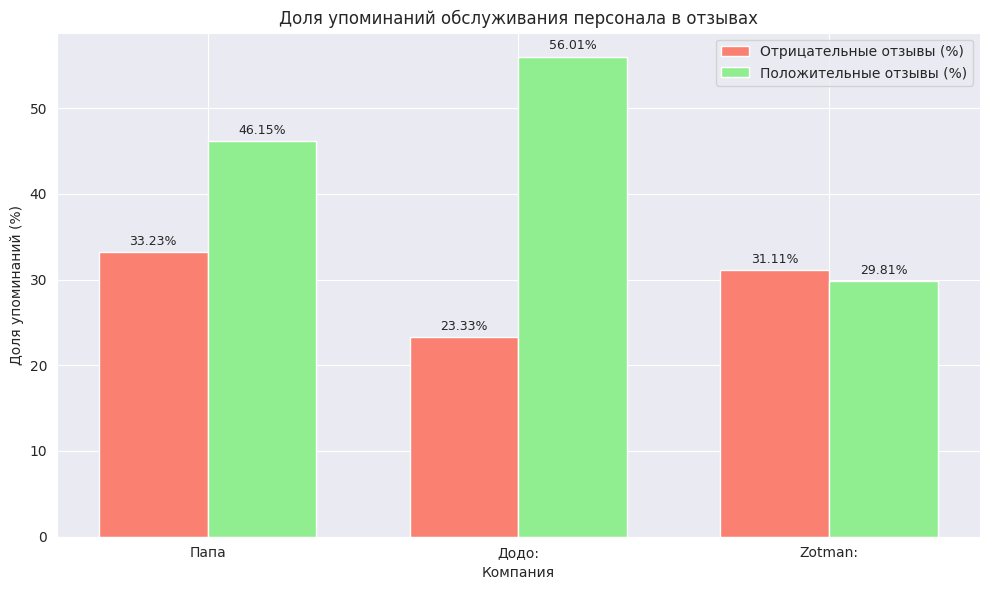

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

staff_keywords = [
    "Персонал", "персонал", "Официант", "официант", "Официанты", "официанты",
    "Обслуживание", "обслуживание", "Сервис", "сервис", "Сотрудники", "сотрудники",
    "Официантка", "официантка", "Администратор", "администратор", "Официанта", "официанта"
]

def contains_staff(reasons):
    return any(any(k in str(r) for k in staff_keywords) for r in reasons)

df["staff_negative"] = df["reason_n"].apply(contains_staff)
df["staff_positive"] = df["reason_p"].apply(contains_staff)

summary = []

for company in df["company"].unique():
    data = df[df["company"] == company]
    
    neg_total = (data["sentiment"] == "negative").sum()
    pos_total = (data["sentiment"] == "positive").sum()
    
    neg_staff = data.loc[data["sentiment"] == "negative", "staff_negative"].sum()
    pos_staff = data.loc[data["sentiment"] == "positive", "staff_positive"].sum()
    
    summary.append({
        "company": company,
        "neg_total": neg_total,
        "neg_staff": neg_staff,
        "neg_staff_share_%": round(100 * neg_staff / neg_total, 2) if neg_total > 0 else 0,
        "pos_total": pos_total,
        "pos_staff": pos_staff,
        "pos_staff_share_%": round(100 * pos_staff / pos_total, 2) if pos_total > 0 else 0,
    })

staff_df = pd.DataFrame(summary)
print(staff_df)

companies = staff_df['company']
neg_share = staff_df['neg_staff_share_%']
pos_share = staff_df['pos_staff_share_%']

x = np.arange(len(companies))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, neg_share, width, label='Отрицательные отзывы (%)', color='salmon')
bars2 = ax.bar(x + width/2, pos_share, width, label='Положительные отзывы (%)', color='lightgreen')

ax.set_xlabel('Компания')
ax.set_ylabel('Доля упоминаний (%)')
ax.set_title('Доля упоминаний обслуживания персонала в отзывах')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.legend()

def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_values(bars1)
add_values(bars2)

plt.tight_layout()
plt.show()

   company  neg_total  neg_clean_atmosphere  neg_clean_atmosphere_share_%  \
0     Папа        620                    61                          9.84   
1    Додо:         60                    19                         31.67   
2  Zotman:         90                    21                         23.33   

   pos_total  pos_clean_atmosphere  pos_clean_atmosphere_share_%  
0        416                    80                         19.23  
1        416                   207                         49.76  
2        426                   160                         37.56  


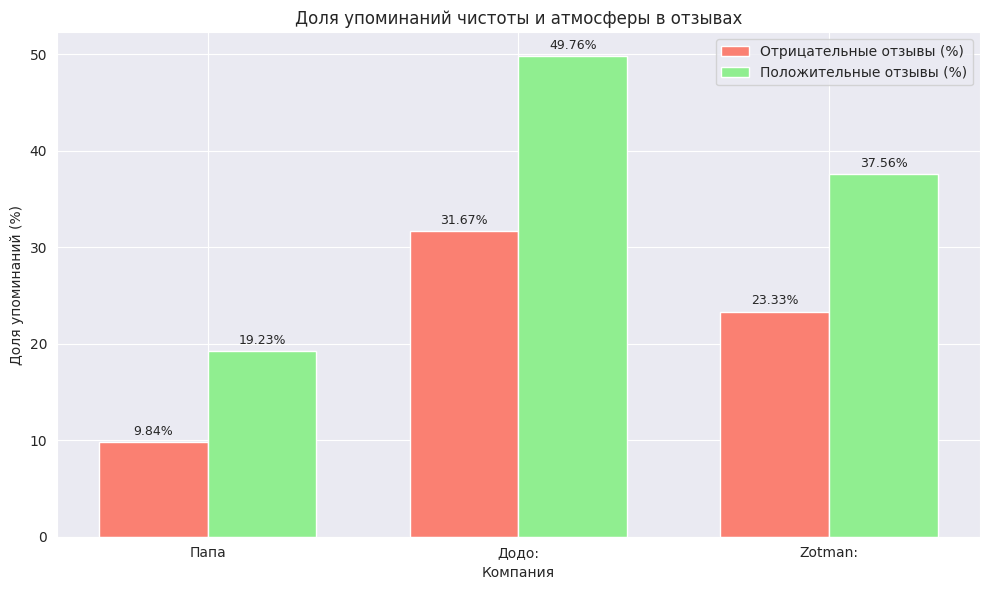

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

clean_atmosphere_keywords = [
    "Чистота", "чистота", "Грязно", "грязно", "Чисто", "чисто",
    "Атмосфера", "атмосфера", "Уют", "уют", "Интерьер", "интерьер",
    "Туалет", "туалет", "Уборка", "уборка", "Санитарные", "санитарные",
    "Мусор", "мусор", "Пыль", "пыль", "Запах", "запах", "Вонь", "вонь"
]

def contains_clean_atmosphere(reasons):
    return any(any(k in str(r) for k in clean_atmosphere_keywords) for r in reasons)

df["clean_atmosphere_negative"] = df["reason_n"].apply(contains_clean_atmosphere)
df["clean_atmosphere_positive"] = df["reason_p"].apply(contains_clean_atmosphere)

summary = []

for company in df["company"].unique():
    data = df[df["company"] == company]
    
    neg_total = (data["sentiment"] == "negative").sum()
    pos_total = (data["sentiment"] == "positive").sum()
    
    neg_clean = data.loc[data["sentiment"] == "negative", "clean_atmosphere_negative"].sum()
    pos_clean = data.loc[data["sentiment"] == "positive", "clean_atmosphere_positive"].sum()
    
    summary.append({
        "company": company,
        "neg_total": neg_total,
        "neg_clean_atmosphere": neg_clean,
        "neg_clean_atmosphere_share_%": round(100 * neg_clean / neg_total, 2) if neg_total > 0 else 0,
        "pos_total": pos_total,
        "pos_clean_atmosphere": pos_clean,
        "pos_clean_atmosphere_share_%": round(100 * pos_clean / pos_total, 2) if pos_total > 0 else 0,
    })

clean_atmosphere_df = pd.DataFrame(summary)
print(clean_atmosphere_df)

companies = clean_atmosphere_df['company']
neg_share = clean_atmosphere_df['neg_clean_atmosphere_share_%']
pos_share = clean_atmosphere_df['pos_clean_atmosphere_share_%']

x = np.arange(len(companies))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, neg_share, width, label='Отрицательные отзывы (%)', color='salmon')
bars2 = ax.bar(x + width/2, pos_share, width, label='Положительные отзывы (%)', color='lightgreen')

ax.set_xlabel('Компания')
ax.set_ylabel('Доля упоминаний (%)')
ax.set_title('Доля упоминаний чистоты и атмосферы в отзывах')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.legend()

def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_values(bars1)
add_values(bars2)

plt.tight_layout()
plt.show()